# DESeq2 DE Analysis Pipeline
- 依赖包:
   - DESeq2
   - RColorBrewer
   - gplots
   - pheatmap
   - ggplot2
- DESeq2对于输入数据的要求
   - 输入数据为整数构成的矩阵
   - 此矩阵必须是没有经过标准化(归一化/Normalize) 
- DESeq2进行差异表达分析
   - 构建dds矩阵
       ```
       dds <- DESeqDataSetFromMatrix(
                   countData = cts, 
                   colData = coldata, 
                   design= ~ batch + condition) 
       #~在R里面用于构建公式对象，~左边为因变量，右边为自变量。
       ```

   - 标准化/归一化
       ```
       dds <- DESeq(dds) 
       #标准化
       ```
   - 差异分析
       ```
       res <- results(dds, contrast=c("condition","treated","control")) 
       #差异分析结果
       ```

1. 读取样本信息（sample.txt）
2. 读取featureCounts产生的各个bam文件的counts信息
3. 检查rawcts中的所有记录(row)的个数，这里代表count到的gene的个数
   - 58721个gene的记录
   - 9个columns，实际上是9列bam文件名信息，geneid被指定为row.names了所以不计在内

In [1]:
### read data ------------------------------------------------------------------------------>

colData <- read.table("sample.csv",header = TRUE)
rawcts <- read.table("../featureCounts/all_feature_fix.csv",header = TRUE,row.names = 1)
dim(rawcts)

[1] 58721     9

In [2]:
# 看一下colData
# 这个东西叫元数据
# 三列分别为样本名称、处理条件、type可以理解为宏观的处理条件
colData

sample,condition,type
<fct>,<fct>,<fct>
Mock_1,ctrl,ctrl
Vector_1,ctrl,ctrl
BE4ALL_1,BE4ALL_1,treat
BE4_1,BE4_1,treat
BE4_2,BE4_2,treat
EM_1,EM_1,treat
EM_2,EM_2,treat
BE4_0706_1,BE4_0706_1,treat
M2_0706_1,M2_0706_1,treat


In [3]:
# 看一下rawcts
# 这个很简单就是geneid为index，样本信息的counts数为columns
head(rawcts)

,X2Mock_1,X2BE4ALL_1,X2Vector_1,BE4_1,BE4_2,EM_1,EM_2,BE4_0706_1,M2_0706_1
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000223972.5,0,0,0,0,0,0,0,0,3
ENSG00000227232.5,359,211,283,340,453,471,622,532,616
ENSG00000278267.1,97,27,40,16,27,10,12,2,2
ENSG00000243485.5,0,0,0,0,0,0,0,0,0
ENSG00000284332.1,0,0,0,0,0,0,0,0,0
ENSG00000237613.2,0,0,0,0,0,0,0,0,0


4. 过滤掉行的和为0，也就是没有bam文件中count到reads的genes
   - 过滤完没有count到的还剩51068个gene

In [4]:
### filt genes that don't express in all sample -------------------------------------------->
rawcts <- rawcts[rowSums(rawcts)>0,]
dim(rawcts)

[1] 51068     9

5. rownames函数调用矩阵的row.names
6. 调用stringr package中的str_split函数，去除geneid中的gene名的.以及后面的内容
7. 使用duplicated函数去掉重复的gn id
   - 发现只有一个重复，也就是说有一个gene因为版本不同被count了两次，但是去duplicate之后只算其中一个的，其实这俩的sequences差不多，所以count数不会差很多，去除哪个都可以

In [5]:
### remove version in ensembl id ----------------------------------------------------------->
gn <- stringr::str_split(rownames(rawcts),"\\.",simplify = T)[,1]
# remove duplicate
rawcts <- rawcts[!duplicated(gn),]
rownames(rawcts) <- gn[!duplicated(gn)]
dim(rawcts)

[1] 51067     9

## 1. 构建dds矩阵

8. 将count的矩阵输入DESeq2的DESeqDataSetFromMatrix函数中，产生dds(DEseq Data Set)


构建dds矩阵需要：

- 表达矩阵
   - 即上述代码中的countData，就是我们前面通过read count计算后并融合生成的矩阵，行row为各个基因，列col为各个样品，中间为计算reads或者fragment得到的整数。我们后面要用的是这个文件（mouse_all_count.txt）
- 样品信息
   - 矩阵即上述代码中的colData，它的类型是一个dataframe（数据框），这个东西叫【元数据】
   - 第一列是样品名称，
   - 第二列是样品的处理情况（对照还是处理等），即condition，condition的类型是一个factor
   - 第三列type可以理解为宏观的处理条件，需要时使用，用不着也可以留空
   
   - 这里我用第三列的type作为自变量(你也可以用第二列的condition)
- 差异比较矩阵
   - 即上述代码中的design。
   - 差异比较矩阵就是告诉差异分析函数是要分析哪些变量间的差异
   - 简单说就是说明哪些是对照哪些是处理。

In [6]:
### DEseq analyses ------------------------------------------------------------------------->
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = rawcts,
                              colData = colData,
                              design = ~ type) 
                            # ~在R里面用于构建公式对象，~左边为因变量(design)，右边为自变量(type) 
dds

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which, which.max, which.min



Attaching package: ‘S4Vectors’


The

class: DESeqDataSet 
dim: 51067 9 
metadata(1): version
assays(1): counts
rownames(51067): ENSG00000223972 ENSG00000227232 ... ENSG00000210195
  ENSG00000210196
rowData names(0):
colnames(9): X2Mock_1 X2BE4ALL_1 ... BE4_0706_1 M2_0706_1
colData names(3): sample condition type

In [7]:
# 预过滤
# 虽然不必在运行DESeq2函数之前对低计数基因进行预过滤，但是有两个原因使预过滤有用：
# - 通过删除读取次数很少的行，我们减小了dds数据对象的内存大小，并且我们提高了DESeq2中转换和测试功能的速度。
# - 在这里，我们执行最小的预过滤，以仅保留总读取次数至少为10的行。
# - 请注意，对结果函数中的归一化计数的平均值进行独立滤波后，会自动应用更严格的滤波以增加功率。

# keep <- rowSums(counts(dds)) >= 10
# dds <- dds[keep,]
# dds

9. 将dds输入DESeq函数#原始dds进行normalize
DESeq包含三步:
- estimation of size factors（estimateSizeFactors)
- estimation of dispersion（estimateDispersons)
- Negative Binomial GLM fitting and Wald statistics（nbinomWaldTest）
- 【可以分布运行，也可用一步到位，最后返回 results可用的DESeqDataSet对象。】

In [8]:
dds <- DESeq(dds)
dds

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 110 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 51067 9 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(51067): ENSG00000223972 ENSG00000227232 ... ENSG00000210195
  ENSG00000210196
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(9): X2Mock_1 X2BE4ALL_1 ... BE4_0706_1 M2_0706_1
colData names(5): sample condition type sizeFactor replaceable

10. Plot Dispersion Estimates
- 观察数据的离散情况
- A simple helper function that plots the per-gene dispersion estimates together with the fitted mean-dispersion relationship.

Arguments
- object
   - a DESeqDataSet, with dispersions estimated
- ymin
   - the lower bound for points on the plot, points beyond this are drawn as triangles at ymin
- genecol
   - the color for gene-wise dispersion estimates
- fitcol
   - the color of the fitted estimates
- finalcol
   - the color of the final estimates used for testing
- legend
   - logical, whether to draw a legend
- [文档](https://www.rdocumentation.org/packages/DESeq2/versions/1.12.3/topics/plotDispEsts)

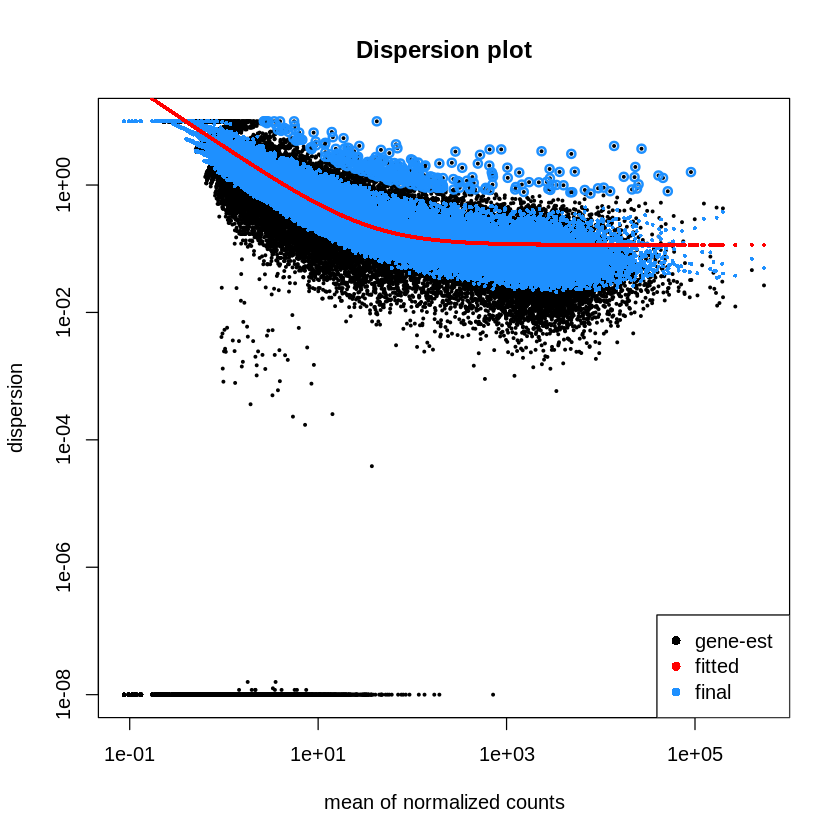

In [9]:
plotDispEsts(dds, main="Dispersion plot")

11. 将结果用results()函数来获取，赋值给res变量

In [10]:
res <- results(dds,contrast=c("type", "treat", "ctrl"))
# summary一下，看一下结果的概要信息
summary(res)


out of 51067 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 21, 0.041%
LFC < 0 (down)     : 114, 0.22%
outliers [1]       : 0, 0%
low counts [2]     : 29702, 58%
(mean count < 11)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



12. normalization前面的数据分布差异

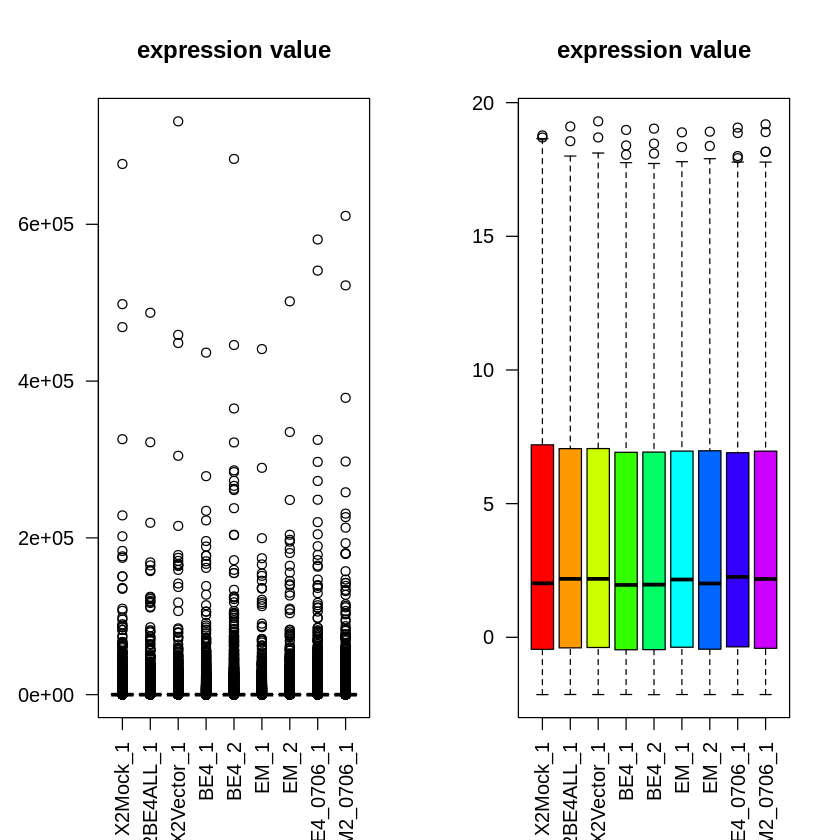

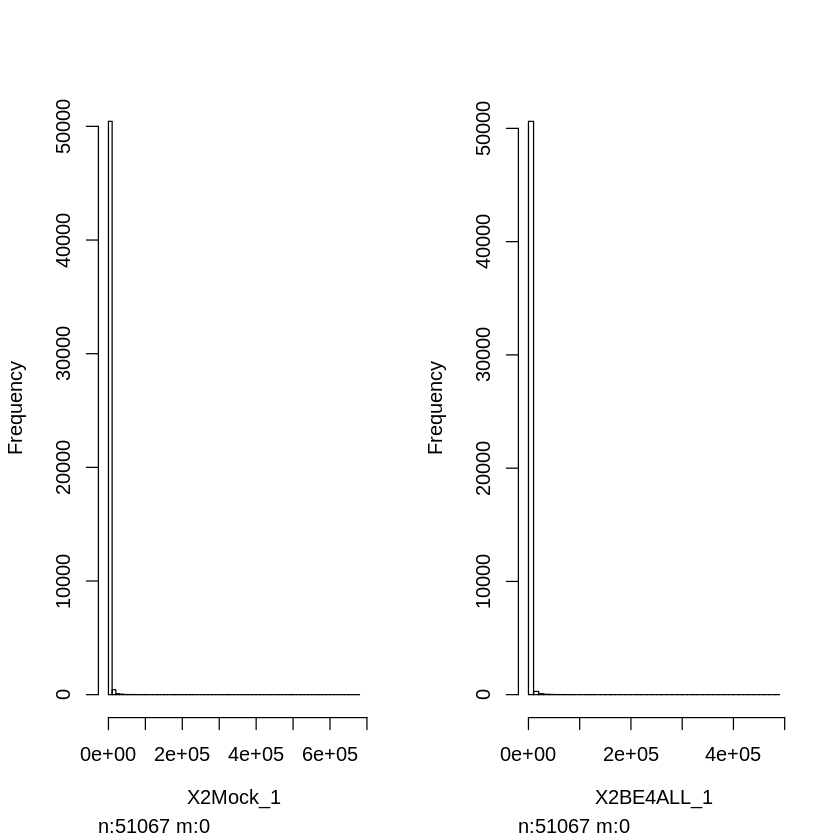

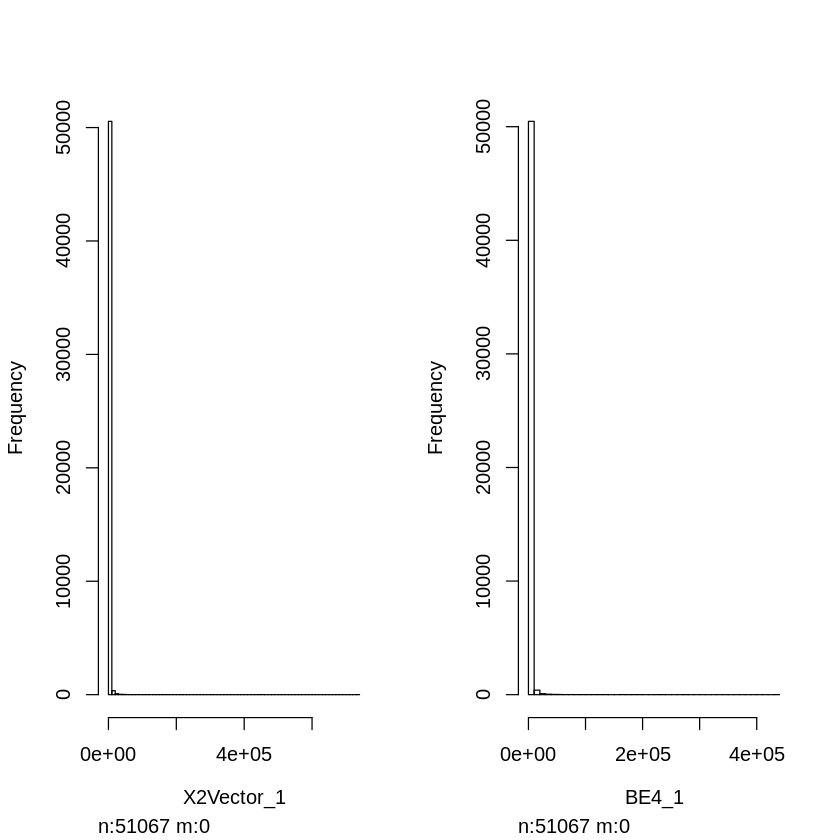

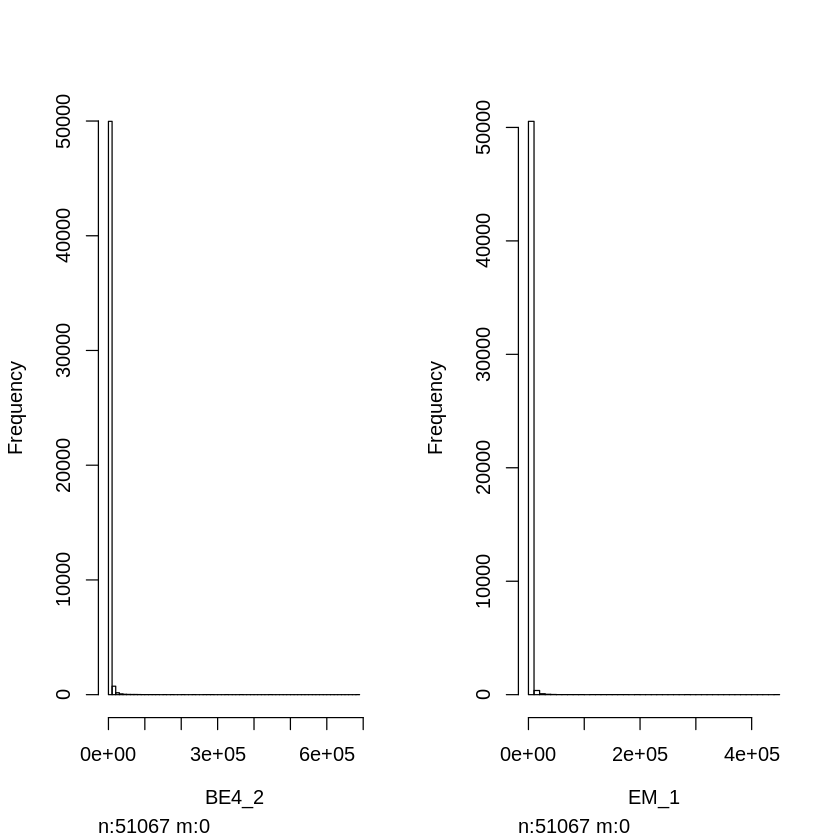

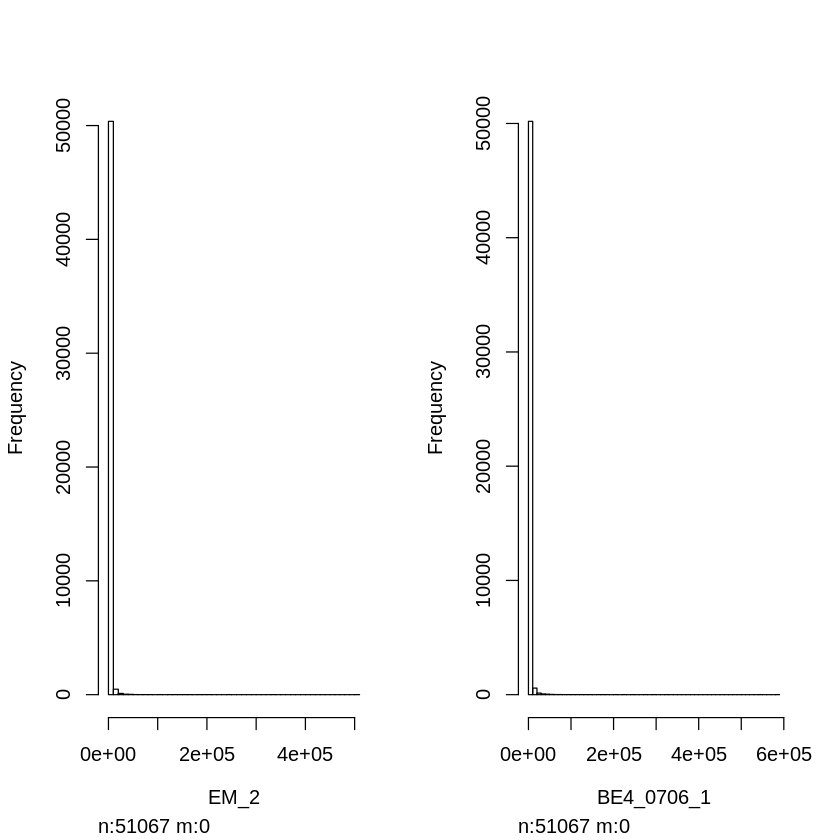

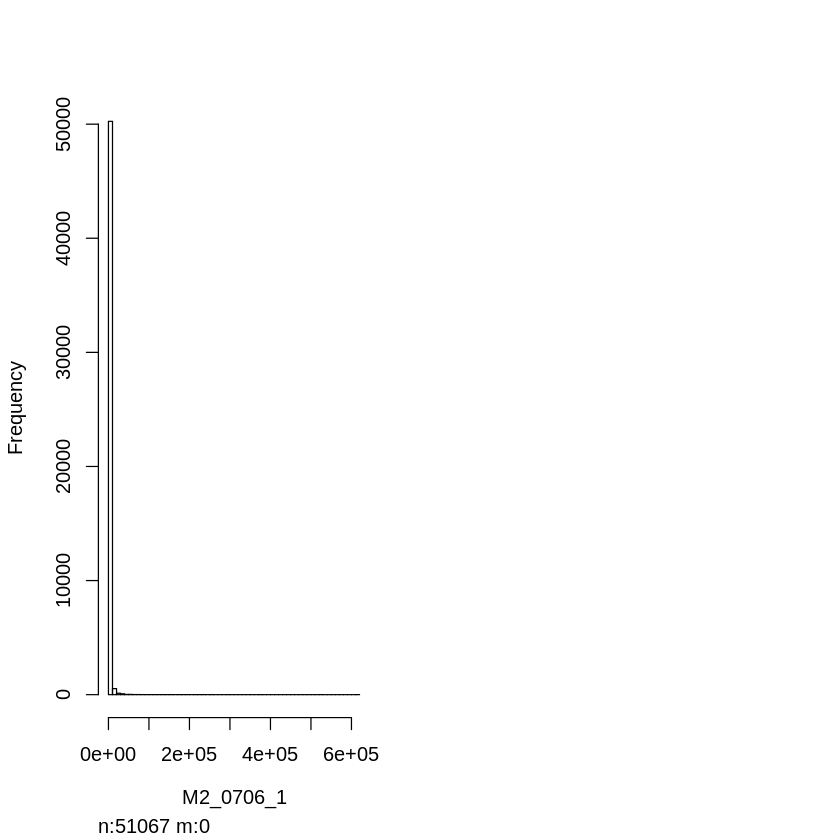

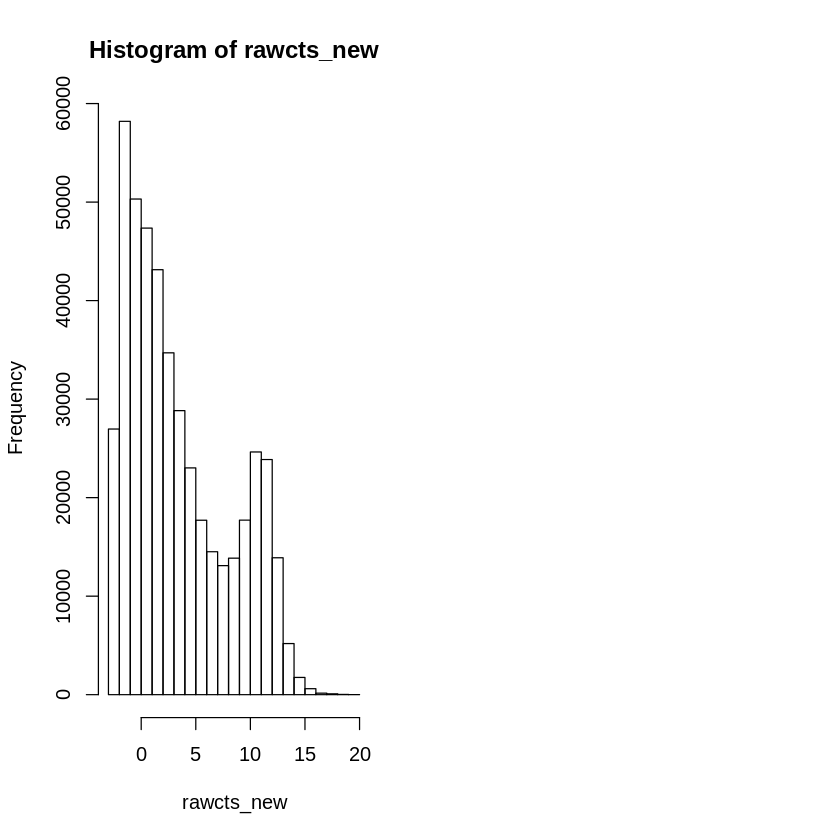

In [11]:
### rld normalization ---------------------------------------------------------------------->
## 下面的代码如果你不感兴趣不需要运行，免得误导你
## 就是看看normalization前面的数据分布差异
rld <- rlogTransformation(dds)
rawcts_new=assay(rld)
par(cex = 0.7)
n.sample=ncol(rawcts)
if(n.sample>40) par(cex = 0.5)
cols <- rainbow(n.sample*1.2)
par(mfrow=c(1,2))
boxplot(rawcts, col = cols,main="expression value",las=2)
boxplot(rawcts_new, col = cols,main="expression value",las=2)
hist(rawcts)
hist(rawcts_new)

13. plot correlation heatmap

In [12]:
# 查看rawcts_new
head(rawcts_new)

,X2Mock_1,X2BE4ALL_1,X2Vector_1,BE4_1,BE4_2,EM_1,EM_2,BE4_0706_1,M2_0706_1
ENSG00000223972,-1.5259582,-1.5151011,-1.5228938,-1.5157765,-1.5301835,-1.5194258,-1.5231616,-1.522956,-1.3035585
ENSG00000227232,8.4227291,8.2071646,8.2785578,8.6424465,8.5336267,8.8650422,9.0415890,8.889296,9.1106137
ENSG00000278267,5.5096777,4.6104106,4.7662849,4.1982610,4.2904464,3.8388628,3.8798551,3.232969,3.2599270
ENSG00000268020,-1.8323172,-1.8247863,-1.8301916,-1.8252548,-1.8352480,-1.8277861,-1.8303774,-1.780107,-1.7783090
ENSG00000240361,-2.1432641,-2.1393490,-2.1421591,-2.1395925,-2.1447878,-2.1409085,-2.1422557,-2.116121,-2.1412469
ENSG00000238009,0.5770922,0.7096266,0.7772214,0.5897573,0.7436665,0.5850412,0.6830461,1.259160,0.8783969


In [13]:
### plot correlation heatmap -------------------------------------------------------------->
library(RColorBrewer)
(mycols <- brewer.pal(8, "Dark2")[1:length(unique(colData$condition))])

[1] "#1B9E77" "#D95F02" "#7570B3" "#E7298A" "#66A61E" "#E6AB02" "#A6761D"
[8] "#666666"

In [14]:
# Sample distance heatmap
sampleDists <- dist(t(rawcts_new))
sampleDistsMatrix <- as.matrix(sampleDists)
sampleDistsMatrix

,X2Mock_1,X2BE4ALL_1,X2Vector_1,BE4_1,BE4_2,EM_1,EM_2,BE4_0706_1,M2_0706_1
X2Mock_1,0.00000,99.33348,86.91331,86.51452,87.45258,101.84923,94.51823,146.17514,137.08545
X2BE4ALL_1,99.33348,0.00000,73.62565,88.82487,87.28111,82.84690,85.07817,86.58167,88.36379
X2Vector_1,86.91331,73.62565,0.00000,90.57253,88.79002,75.45099,77.25746,113.57619,107.15774
BE4_1,86.51452,88.82487,90.57253,0.00000,37.13054,76.27030,63.23900,122.16124,114.70301
BE4_2,87.45258,87.28111,88.79002,37.13054,0.00000,76.34148,63.27054,121.41360,114.01073
EM_1,101.84923,82.84690,75.45099,76.27030,76.34148,0.00000,50.42888,104.07887,98.95877
EM_2,94.51823,85.07817,77.25746,63.23900,63.27054,50.42888,0.00000,109.56704,100.61082
BE4_0706_1,146.17514,86.58167,113.57619,122.16124,121.41360,104.07887,109.56704,0.00000,60.52659
M2_0706_1,137.08545,88.36379,107.15774,114.70301,114.01073,98.95877,100.61082,60.52659,0.00000


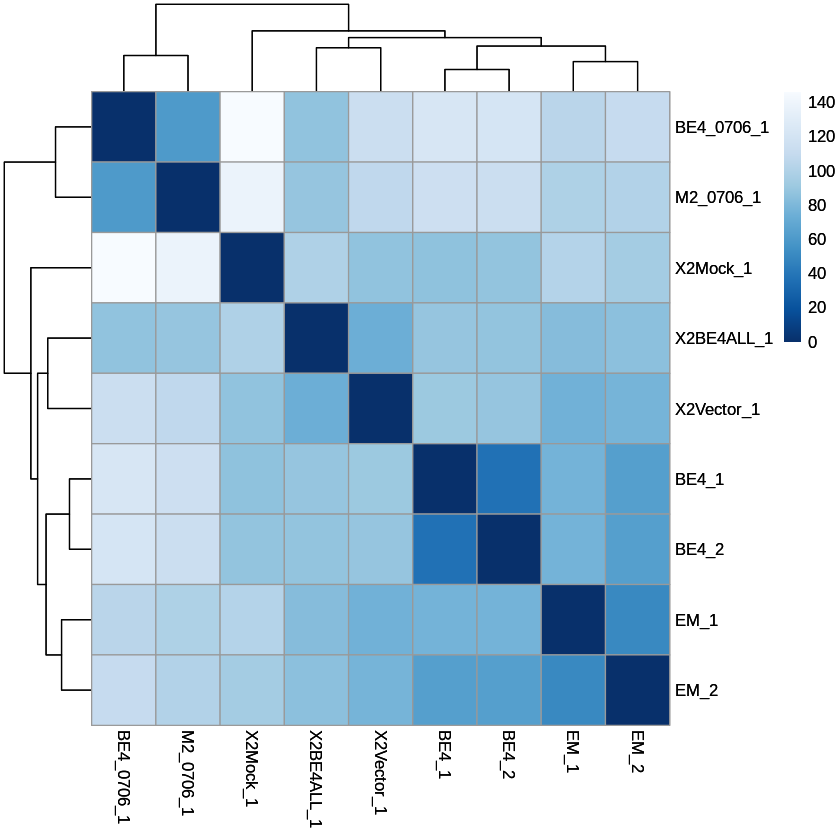

In [30]:
library(gplots)
library(pheatmap)
png("qc-heatmap-samples.png", w=1000, h=1000, pointsize=20)
#heatmap.2(sampleDistsMatrix, key=F, trace="none",
#         col=colorpanel(100, "black", "white"),
#          ColSideColors=mycols[colData$condition], RowSideColors=mycols[colData$condition],
#          margin=c(10, 10), main="Sample Distance Matrix")
colors <- colorRampPalette(rev(brewer.pal(9,"Blues")))(255)
ht <- pheatmap(sampleDistsMatrix,
               clustering_distance_cols = sampleDists,
               clustering_distance_rows = sampleDists,
               color = colors
              )
ht

14. MA plot
- log2 折叠变换和平均正常统计量的关系，红色的点表示在10%FDR的基因

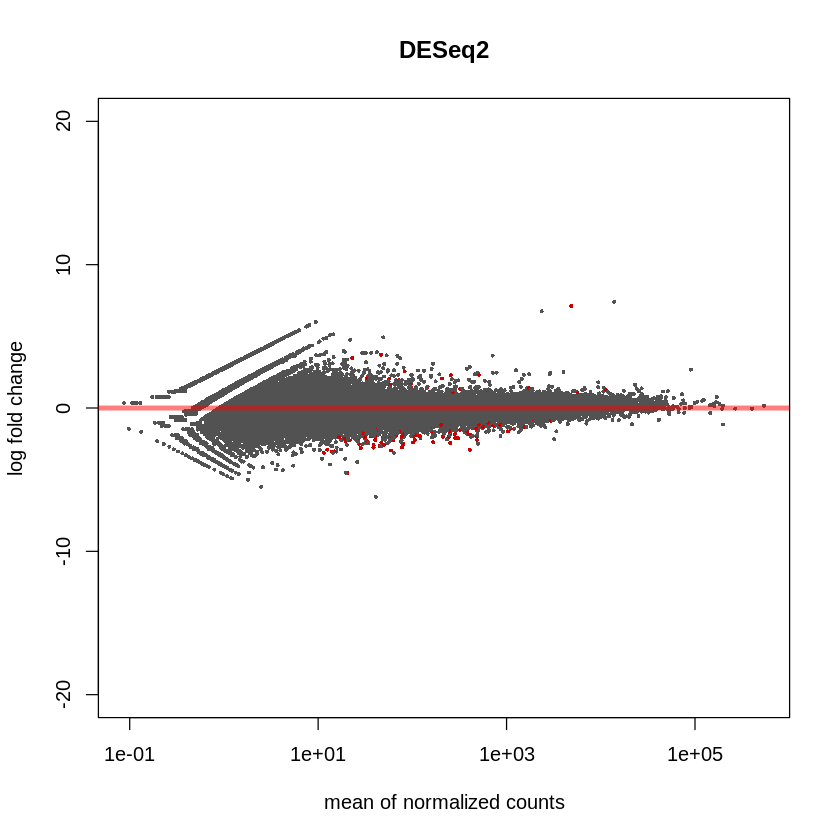

In [16]:
### MA plot ------------------------------------------------------------------------------>
par(mfrow=c(1,1))
DESeq2::plotMA(res, main="DESeq2", ylim=c(-20,20))

15. nbinomTest的p值统计直方图

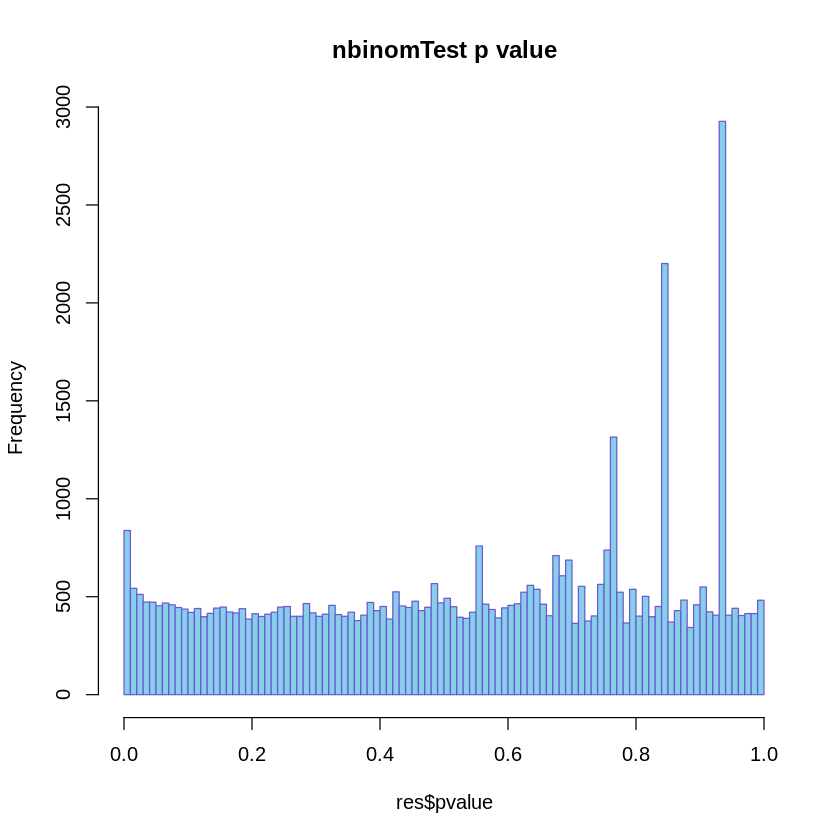

In [17]:
hist(res$pvalue, breaks = 100, col = 'skyblue', border = 'slateblue', main = 'nbinomTest p value')

16. vst normalization

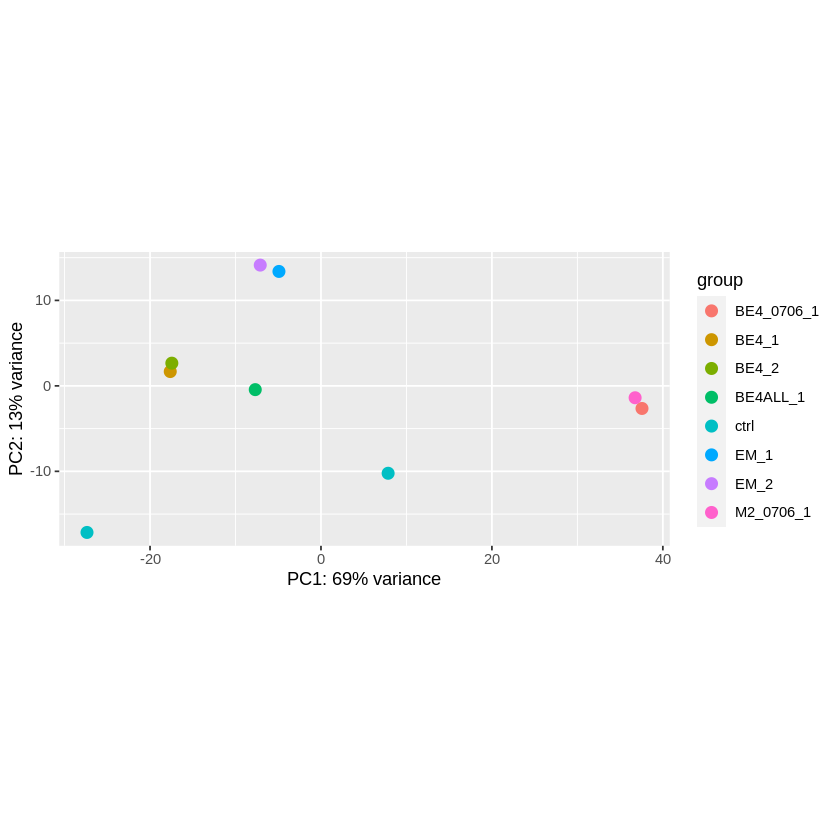

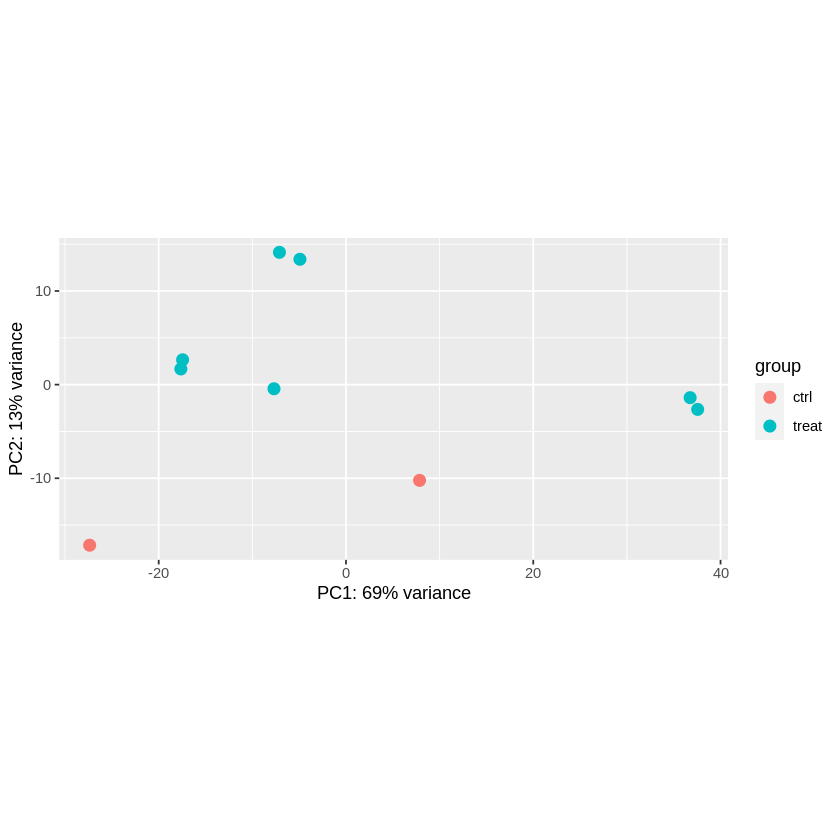

In [18]:
### vst normalization -------------------------------------------------------------------->
vsd <- vst(dds, blind = FALSE)
plotPCA(vsd,intgroup=c("condition"))
plotPCA(vsd,intgroup=c("type"))

[1] "Intercept"          "type_treat_vs_ctrl"


out of 51067 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 21, 0.041%
LFC < 0 (down)     : 114, 0.22%
outliers [1]       : 0, 0%
low counts [2]     : 29702, 58%
(mean count < 11)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895



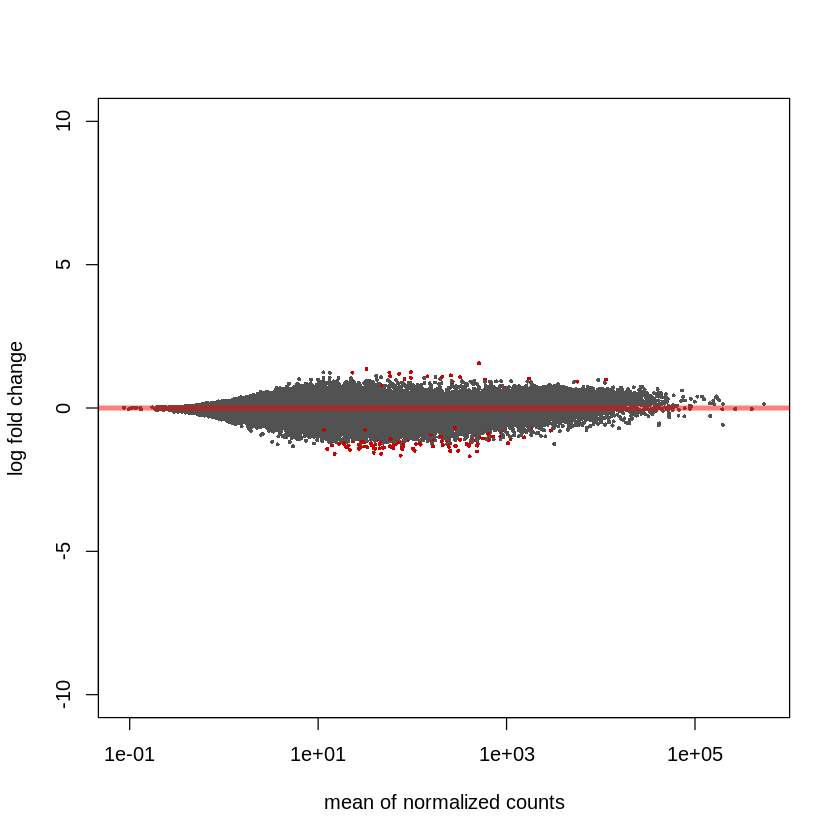

In [19]:
#plotPCA(rld, intgroup=c("condition"))
resultsNames(dds)
summary(res)
reslfc <- lfcShrink(dds,coef = "type_treat_vs_ctrl")
plotMA(reslfc, ylim=c(-10,10))

d <- plotCounts(dds,gene=which.min(res$padj), intgroup = "type",returnData = TRUE)

17. 这个heatmap干嘛的？

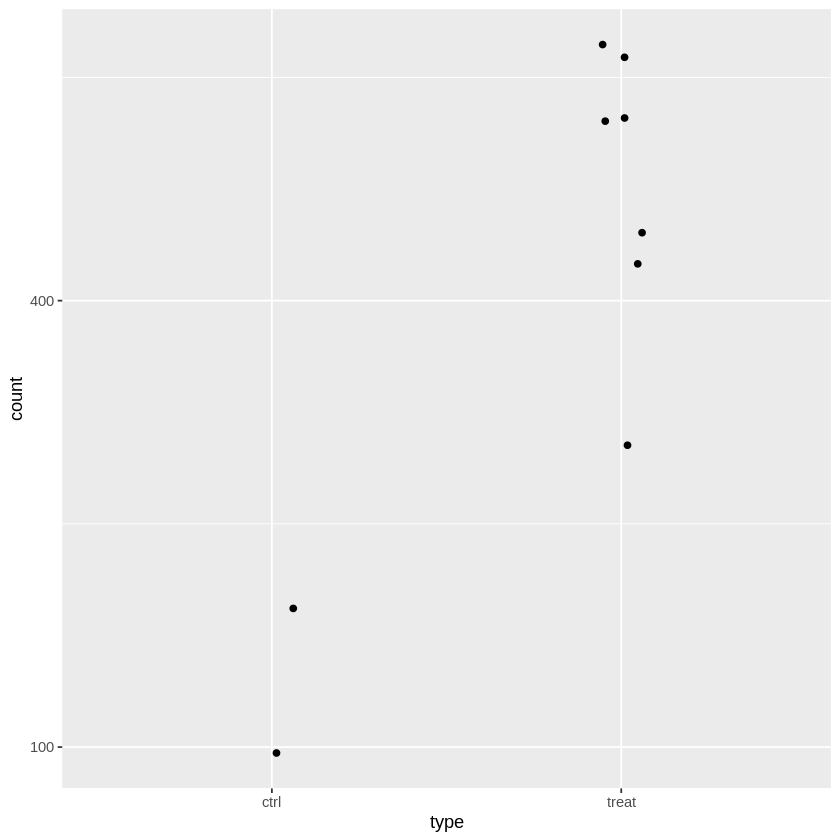

In [20]:
library(ggplot2)
ggplot(d,aes(x=type,y=count))+
  geom_point(position = position_jitter(w=0.1,h=0))+
  scale_y_log10(breaks=c(25,100,400))

18. 处理res数据并且输出DEG表格

In [27]:
### deal with res and extract DEG!!! ----------------------------------------------------->
colData(dds)
head(vsd)
summary(res)
resOrdered <- res[order(res$padj),]
resOrdered[which(resOrdered$log2FoldChange >= 1 & resOrdered$padj < 0.05),'sig'] <- 'up'
resOrdered[which(resOrdered$log2FoldChange <= -1 & resOrdered$padj < 0.05),'sig'] <- 'down'
resOrdered[which(abs(resOrdered$log2FoldChange) <= 1 | resOrdered$padj >= 0.05),'sig'] <- 'none'
resOrdered=as.data.frame(resOrdered)
write.table(resOrdered,"../featureCounts/deseq2.all_sample.results.csv",col.names = NA, sep = "\t", quote = FALSE)

deg <- subset(resOrdered, padj < 0.05 & abs(log2FoldChange >1)) ##### extract DEG !
deg_matrix <- as.data.frame(deg)
head(deg_matrix)
write.table(deg_matrix, '../featureCounts/deg_result.csv', col.names = NA, sep = "\t", quote = FALSE)

DataFrame with 9 rows and 5 columns
               sample  condition     type        sizeFactor replaceable
             <factor>   <factor> <factor>         <numeric>   <logical>
X2Mock_1       Mock_1       ctrl     ctrl  1.13640479577511       FALSE
X2BE4ALL_1   Vector_1       ctrl     ctrl 0.841479013384197       FALSE
X2Vector_1   BE4ALL_1   BE4ALL_1    treat  1.04400417899461        TRUE
BE4_1           BE4_1      BE4_1    treat 0.857355170067424        TRUE
BE4_2           BE4_2      BE4_2    treat  1.27737044235641        TRUE
EM_1             EM_1       EM_1    treat 0.948463724772527        TRUE
EM_2             EM_2       EM_2    treat  1.05177109023014        TRUE
BE4_0706_1 BE4_0706_1 BE4_0706_1    treat  1.04579694081031        TRUE
M2_0706_1   M2_0706_1  M2_0706_1    treat 0.973419005555518        TRUE

class: DESeqTransform 
dim: 6 9 
metadata(1): version
assays(1): ''
rownames(6): ENSG00000223972 ENSG00000227232 ... ENSG00000240361
  ENSG00000238009
rowData names(23): baseMean baseVar ... replace dispFit
colnames(9): X2Mock_1 X2BE4ALL_1 ... BE4_0706_1 M2_0706_1
colData names(5): sample condition type sizeFactor replaceable


out of 51067 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 21, 0.041%
LFC < 0 (down)     : 114, 0.22%
outliers [1]       : 0, 0%
low counts [2]     : 29702, 58%
(mean count < 11)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sig
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000198576,509.56957,2.306038,0.4471538,5.157148,2.507403e-07,0.003846467,up
ENSG00000283538,96.07542,1.679979,0.4013559,4.185758,2.842156e-05,0.029832882,up
ENSG00000279501,32.64605,2.068240,0.5006098,4.131441,3.604965e-05,0.032360548,up
ENSG00000172965,322.13968,1.318878,0.3285761,4.013919,5.971883e-05,0.041157831,up


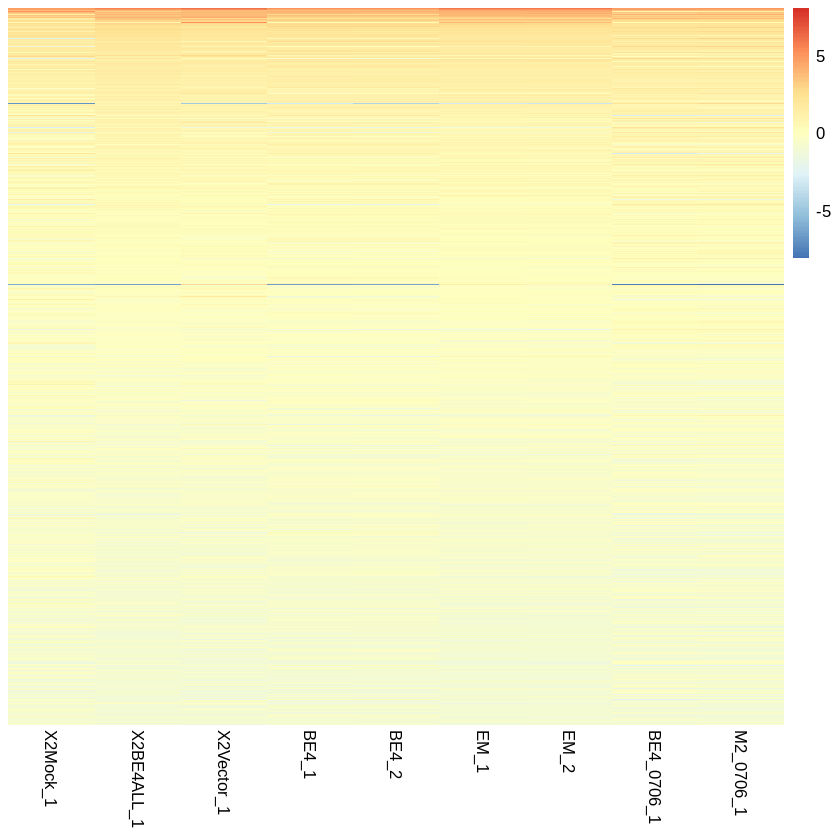

In [35]:
### plot heatmap ------------------------------------------------------------------------->
### plot all genes heatmap
select <- order(rowMeans(counts(dds,normalized=TRUE)),
                decreasing=TRUE)[1:1000]  ### select first ordered 1000 genes(not deg)
#                 decreasing=TRUE)[1:50]  ### select first ordered 66 genes(not deg)
df <- as.data.frame(colData(dds)[,c("type")])
pheatmap(assay(vsd)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE,scale = "column")

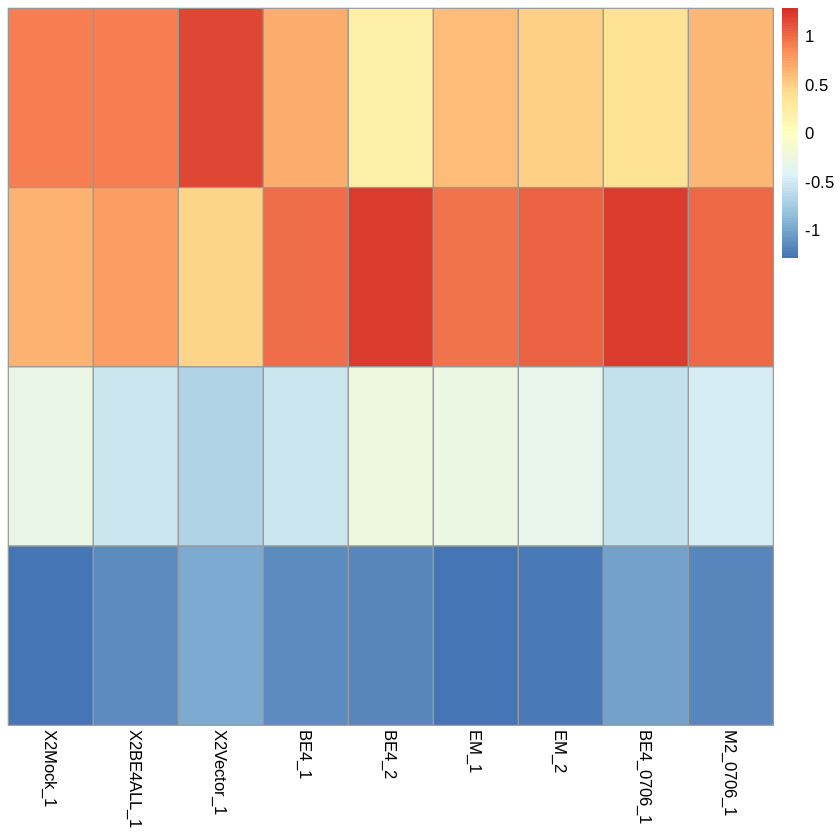

In [36]:
### plot DEG heatmap
selected <- rownames(deg)
pheatmap(assay(vsd)[rownames(vsd) %in% selected,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE, scale = "column")

Warning message:
“Removed 29702 rows containing missing values (geom_point).”


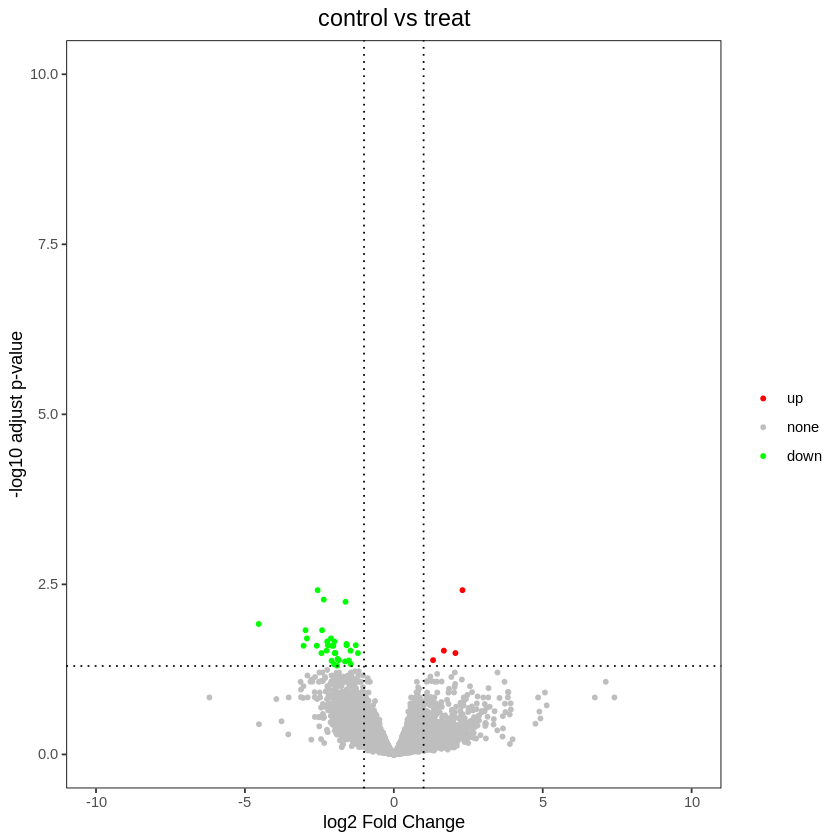

In [37]:
### plot valcano ------------------------------------------------------------------------>
vp <- ggplot(data = resOrdered, aes(x = log2FoldChange, y = -log10(padj),color = sig)) +
  geom_point(size = 1) +  #绘制散点图
  scale_color_manual(values = c('red', 'gray', 'green'), limits = c('up', 'none', 'down')) +  #自定义点的颜色
  labs(x = 'log2 Fold Change', y = '-log10 adjust p-value', title = 'control vs treat', color = '') +  #坐标轴标题
  theme(plot.title = element_text(hjust = 0.5, size = 14), panel.grid = element_blank(), #背景色、网格线、图例等主题修改
        panel.background = element_rect(color = 'black', fill = 'transparent'),
        legend.key = element_rect(fill = 'transparent')) +
  geom_vline(xintercept = c(-1, 1), lty = 3, color = 'black') +  #添加阈值线
  geom_hline(yintercept = 1.3, lty = 3, color = 'black') +
  xlim(-10, 10) + ylim(0, 10)
vp